# SIV Project: Board Game Analysis
**Students:** Federico Berra and Davide Verzotto

## 1. Environment Setup & Tools

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

cv2.setRNGSeed(42)
np.random.seed(42)

try:
    from cv2.xfeatures2d import matchGMS
    HAS_GMS = True
except (ImportError, AttributeError):
    if hasattr(cv2, "matchGMS"):          
        matchGMS = cv2.matchGMS
        HAS_GMS = True
    else:
        HAS_GMS = False
        print("WARNING: matchGMS unavailable -> using Lowe’s ratio test instead.")


def show_image(img, title="Image", cmap=None):
    plt.figure(figsize=(10, 8))
    if len(img.shape) == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("on")
    plt.show()

print("Setup Complete. Tools are ready!")

Setup Complete. Tools are ready!


## 2. Manual Corner Selection

In [ ]:
def pick_points(image_path):
    """Opens the image and collects the clicked points (press any key to close)."""
    img = cv2.imread(image_path)
    points = []

    def click_event(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN:
            points.append((x, y))
            print("Clicked:", x, y)

    cv2.imshow("image", img)
    cv2.setMouseCallback("image", click_event)
    cv2.waitKey(0)
    cv2.destroyAllWindows()
    return points

folder_path = "../dataset/Game_2/"
files = sorted(f for f in os.listdir(folder_path)
               if f.lower().endswith((".png", ".jpg", ".jpeg")))
print("First frame:", files[0])   

pts = pick_points(os.path.join(folder_path, files[0]))
print("Clicked points:", pts)

Primo frame: 001.png
Punti cliccati: []


## 3. Rectified Reference Images
The empty board reference defines the **common coordinate system** into which all frames are mapped.

In [3]:
def rotate_left(image):
    return cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE)


def build_reference(image_path, src_pts, dst_size, dst_pts):
    raw = cv2.imread(image_path)
    if raw is None:
        raise FileNotFoundError(image_path)
    M = cv2.getPerspectiveTransform(np.float32(src_pts), np.float32(dst_pts))
    return cv2.warpPerspective(raw, M, dst_size)


# Complete board 
BoardW, BoardH = 1105, 740
fixed_emptyBoard = build_reference(
   "../dataset/Game_2/001.png",
   [(412, 137), (1523, 132), (1522, 868), (411, 868)],   
   (BoardW, BoardH),
   [[0, 0], [BoardW - 1, 0], [BoardW - 1, BoardH - 1], [0, BoardH - 1]],
)

# #board corners
# board_src = np.float32([[91,16], [885, 19], [920, 1260], [50, 1260]])
# BoardW, BoardH = 1105, 740
# board_dst = np.float32([ [0, BoardH-1],[0, 0], [BoardW-1, 0], [BoardW-1, BoardH-1]])
# rawemptyBoard = cv2.imread("../dataset/empty_board/complete.jpg")
# boardmatrix = cv2.getPerspectiveTransform(board_src, board_dst)
# fixed_emptyBoard = cv2.warpPerspective(rawemptyBoard, boardmatrix, (BoardW, BoardH))

# show_image(fixed_emptyBoard, "Fixed Empty Board")


# Trajectory geometry
BORDERS = (40, 54, 40, 38)   # top, bottom, left, right

def build_ring_mask(w, h, borders):
    bt, bb, bl, br = borders
    mask = np.zeros((h, w), dtype=np.uint8)
    mask[0:bt, :] = 255
    mask[h - bb:h, :] = 255
    mask[:, 0:bl] = 255
    mask[:, w - br:w] = 255
    return mask

ring_mask = build_ring_mask(BoardW, BoardH, BORDERS)

## 4. Localization via Homography and Exact Alignment

`align_to_reference`: maps the game frame **pixel by pixel** into the same coordinate system as the empty reference image (same size, same alignment). This is essential for the difference computation in Section 6: if the images are not aligned pixel-wise, the printed numbers will not be removed.

In [4]:
def findImage(imageToFind, WholeImage, show_matches=False, return_mask=False):
    """Finds 'imageToFind' (reference) inside 'WholeImage' and reprojects
    WholeImage into the reference coordinate system."""
    orb = cv2.ORB_create(nfeatures=5000)
    kp1, des1 = orb.detectAndCompute(imageToFind, None)
    kp2, des2 = orb.detectAndCompute(WholeImage, None)

    if des1 is None or des2 is None:
        return None

    if (HAS_GMS):
        matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
        matches = matcher.match(des1, des2)
        good = matchGMS(
            imageToFind.shape[:2], WholeImage.shape[:2],
            kp1, kp2, matches,
            withRotation=False, withScale=True, thresholdFactor=6,
        )
    else:
        matcher = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
        knn = matcher.knnMatch(des1, des2, k=2)
        good = [m for m, n in knn if m.distance < 0.75 * n.distance]

    if len(good) < 3:                     
        return None

    src_pts = np.float32([kp1[m.queryIdx].pt for m in good]).reshape(-1, 2)   
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in good]).reshape(-1, 2)

    M, inlier_mask = cv2.estimateAffinePartial2D(dst_pts, src_pts, method=cv2.RANSAC, ransacReprojThreshold=3.0, maxIters=3000, confidence=0.99, refineIters=10,)
    if M is None:
        return None

    if show_matches:
        inliers = [m for m, keep in zip(good, inlier_mask.ravel().astype(bool)) if keep]
        show_image(
            cv2.drawMatches(imageToFind, kp1, WholeImage, kp2, inliers, None,
                            flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS),
            "Inlier Matches",
        )

    H = np.vstack([M, [0.0, 0.0, 1.0]]).astype(np.float32)   
    out_size = (imageToFind.shape[1], imageToFind.shape[0])
    warped = cv2.warpPerspective(WholeImage, H, out_size)
    if not return_mask:
        return warped
    ones = np.full(WholeImage.shape[:2], 255, np.uint8)
    vmask = cv2.warpPerspective(ones, H, out_size,
                                flags=cv2.INTER_NEAREST,
                                borderMode=cv2.BORDER_CONSTANT, borderValue=0)
    return warped, vmask


def findPart(referenceSections, completeImage, show_matches=False):
    for ref in referenceSections:
        result = findImage(ref, completeImage, show_matches=show_matches)
        if result is None:
            print("Localization failed at one step of the cascade.")
            return completeImage
        completeImage = result
    return completeImage


def crop_image(image, pLeft, pRight, pTop, pBottom):
    height, width = image.shape[:2]
    return image[int(height * pTop): height - int(height * pBottom),
                 int(width * pLeft): width - int(width * pRight)]


def refine_with_ecc(aligned, ref, mask=None, gauss=5, valid_in=None):
    if valid_in is None:
        valid_in = np.full(aligned.shape[:2], 255, np.uint8)

    g_ref = cv2.cvtColor(ref, cv2.COLOR_BGR2GRAY)
    g_img = cv2.cvtColor(aligned, cv2.COLOR_BGR2GRAY)
    warp = np.eye(3, 3, dtype=np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 300, 1e-6)
    try:
        cc, warp = cv2.findTransformECC(g_ref, g_img, warp,
                                        cv2.MOTION_HOMOGRAPHY, criteria, mask, gauss)
    except cv2.error:
        return aligned, valid_in

    h, w = ref.shape[:2]
    aligned_warped = cv2.warpPerspective(aligned, warp, (w, h),
                                         flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP)
    valid_out = cv2.warpPerspective(valid_in, warp, (w, h),
                                    flags=cv2.INTER_NEAREST + cv2.WARP_INVERSE_MAP,
                                    borderMode=cv2.BORDER_CONSTANT, borderValue=0)
    return aligned_warped, valid_out


def find_board_corners(frame, debug=False):
    """Finds the 4 corners of the board (largest dark quadrilateral)."""
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    # il tavolo è blu/chiaro, il tabellone scuro: maschera per bassa luminosità
    dark = cv2.inRange(hsv, (0, 0, 0), (180, 255, 110))
    dark = cv2.morphologyEx(dark, cv2.MORPH_CLOSE, np.ones((25, 25), np.uint8))
    dark = cv2.morphologyEx(dark, cv2.MORPH_OPEN,  np.ones((15, 15), np.uint8))
    if debug:
        show_image(dark, "Board mask", cmap='gray')

    contours, _ = cv2.findContours(dark, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    board = max(contours, key=cv2.contourArea)
    if cv2.contourArea(board) < 0.15 * frame.shape[0] * frame.shape[1]:
        return None   

    peri = cv2.arcLength(board, True)
    for eps in (0.02, 0.03, 0.05):
        approx = cv2.approxPolyDP(board, eps * peri, True)
        if len(approx) == 4:
            return approx.reshape(4, 2).astype(np.float32)
    return None


def order_corners(pts):
    """Sorts the 4 points: top-left, top-right, bottom-right, bottom-left."""
    s = pts.sum(axis=1); d = np.diff(pts, axis=1).ravel()
    return np.float32([pts[np.argmin(s)], pts[np.argmin(d)],
                       pts[np.argmax(s)], pts[np.argmax(d)]])


def align_to_reference(frame):
    """ORB/similarity + monitored ECC refinement: each ECC step is
    accepted only if it improves the alignment score."""
    res = findImage(fixed_emptyBoard, frame, return_mask=True)
    if res is None:
        return None, None
    best_out, best_valid = res
    best_s = alignment_score(best_out, fixed_emptyBoard, valid=best_valid)

    for g in (21, 5):
        cand, cand_valid = refine_with_ecc(best_out, fixed_emptyBoard,
                                           mask=ring_mask, gauss=g, valid_in=best_valid)
        s = alignment_score(cand, fixed_emptyBoard, valid=cand_valid)
        if s > best_s:
            best_out, best_valid, best_s = cand, cand_valid, s

    if best_s <= 0.10:
        return None, None
    return best_out, cv2.erode(best_valid, np.ones((7, 7), np.uint8))


def alignment_score(out, ref, valid=None):
    """Correlation with the reference in the track band, using only valid pixels."""
    zone = ring_mask.copy()
    if valid is not None:
        zone = cv2.bitwise_and(zone, valid)
    if cv2.countNonZero(zone) < 500:      
        return -1.0
    g1 = cv2.cvtColor(out, cv2.COLOR_BGR2GRAY)[zone > 0].astype(np.float32)
    g2 = cv2.cvtColor(ref, cv2.COLOR_BGR2GRAY)[zone > 0].astype(np.float32)
    return np.corrcoef(g1, g2)[0, 1]

### Test di allineamento su un frame

Loaded: 001.png


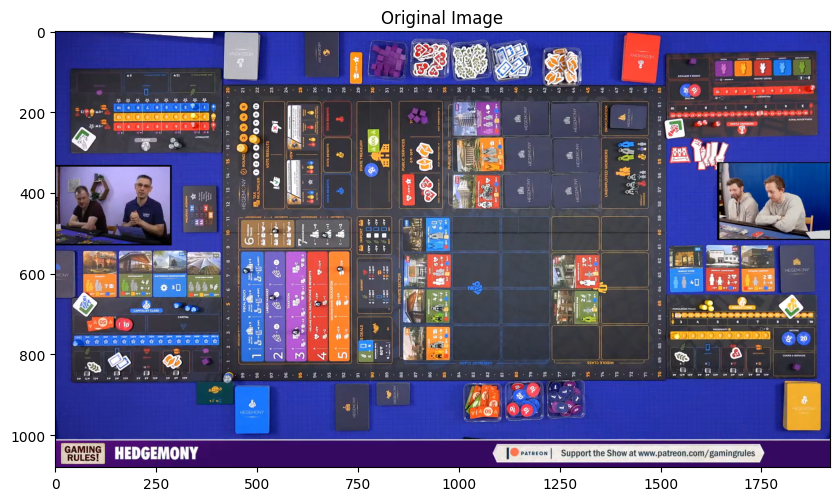

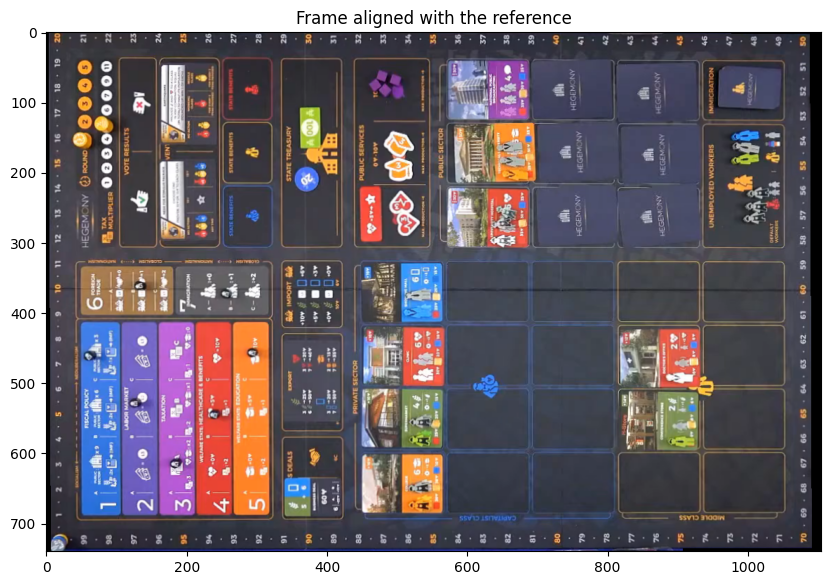

In [6]:
folder_path = "../dataset/Game_2/"
#image_name = sorted(os.listdir(folder_path))[2]
image_name = "001.png"
img = cv2.imread(os.path.join(folder_path, image_name))
print("Loaded:", image_name)

aligned, valid_mask = align_to_reference(img)
if aligned is None:
    raise RuntimeError("Frame aligned with the reference")

masked=cv2.bitwise_and(aligned, aligned, mask=valid_mask)
show_image(img, "Original Image")
show_image(masked, "Frame aligned with the reference")

## 5. Scoring Track Model (built only once)

The 0–99 scoring track runs along the board perimeter: the cells are equally spaced along each side, so their positions can be geometrically computed in the reference image coordinates. On the Hegemony board, the layout is:

- **bottom edge** (from left to right): 0, 99, 98, …, 70
- **left edge** (from bottom to top): 1 … 19
- **top edge** (from left to right): 20 … 50
- **right edge** (from top to bottom): 51 … 69

**Verification using the overlay below:** each drawn number should fall on the corresponding cell of the empty board. If something does not match, adjust `BORDERS` (band thickness) or the score lists for each side.

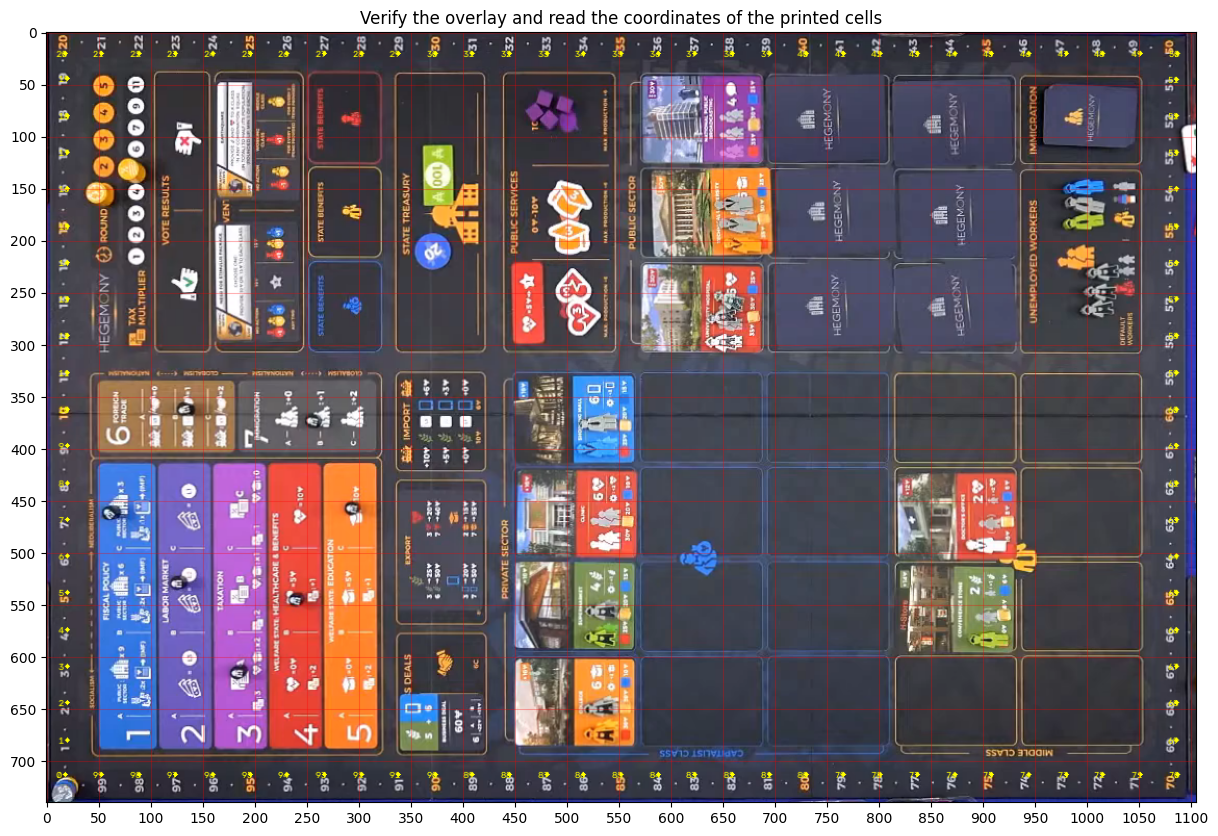

In [8]:
# SCORING TRACK CONFIGURATION
SCORES_BOTTOM = [0] + list(range(99, 69, -1))   
SCORES_LEFT   = list(range(1, 20))              
SCORES_TOP    = list(range(20, 51))             
SCORES_RIGHT  = list(range(51, 70))             

# CALIBRATION: coordinates of the cell centers at the endpoints of each side
# Read these 8 values from the red grid (accuracy +/-5 px) and replace them.
x20, x50 = 18, 1087     # UPPER edge
x0,  x70 = 18, 1087     # BOTTOM edge
y1,  y19 = 680, 45      # LEFT edge
y51, y69 = 45, 680      # RIGHT edge
# -------------------------------------------------------------------------------------


def span_from_centers(c_first, c_last, n):
    """Span such that the first and last cell fall exactly on c_first and c_last."""
    d = (c_last - c_first) / (n - 1)
    return (c_first - d / 2, c_last + d / 2)


SPAN_TOP    = span_from_centers(x20, x50, len(SCORES_TOP))
SPAN_BOTTOM = span_from_centers(x0,  x70, len(SCORES_BOTTOM))
SPAN_LEFT   = span_from_centers(y1,  y19, len(SCORES_LEFT))
SPAN_RIGHT  = span_from_centers(y51, y69, len(SCORES_RIGHT))


def _spread(scores, span, fixed_coord, axis):
    a, b = span
    n = len(scores)
    out = {}
    for i, s in enumerate(scores):
        pos = int(a + (i + 0.5) * (b - a) / n)
        out[s] = (pos, fixed_coord) if axis == "x" else (fixed_coord, pos)
    return out


def build_track_model(w, h, borders):
    bt, bb, bl, br = borders
    cells = {}
    cells.update(_spread(SCORES_BOTTOM, SPAN_BOTTOM, h - bb // 2, "x"))
    cells.update(_spread(SCORES_LEFT,   SPAN_LEFT,   bl // 2,      "y"))
    cells.update(_spread(SCORES_TOP,    SPAN_TOP,    bt // 2,      "x"))
    cells.update(_spread(SCORES_RIGHT,  SPAN_RIGHT,  w - br // 2,  "y"))
    return cells


track_cells = build_track_model(BoardW, BoardH, BORDERS)

# Calibration verification overlay with grid 
overlay = fixed_emptyBoard.copy()
for score, (x, y) in track_cells.items():
    cv2.circle(overlay, (x, y), 2, (0, 255, 255), -1)
    cv2.putText(overlay, str(score), (x - 8, y + 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 255, 255), 1)

plt.figure(figsize=(16, 10))
plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.xticks(range(0, BoardW, 50))
plt.yticks(range(0, BoardH, 50))
plt.grid(True, color='red', alpha=0.3)
plt.title("Verify the overlay and read the coordinates of the printed cells")
plt.show()

## 6. Detection of Scoring Discs

Within the scoring track region, we compute the difference between the aligned frame and the empty reference: the printed graphics are removed, while the discs (and hands) become visible. The detected blobs are filtered by size and classified by color (HSV) to determine which class they belong to.

In [9]:
# DETECTION PARAMETERS 
DIFF_THRESHOLD  = 60     # threshold on the difference (0-255)
MIN_TOKEN_AREA  = 60     # minimum blob area (px^2)
MAX_TOKEN_AREA  = 2000   # maximum blob area
MAX_TOKEN_SIZE  = 35     # maximum bounding box side length (filters out hands/arms)

# Pre-blurred reference computed only once (reduces difference noise)
_empty_blur = cv2.GaussianBlur(fixed_emptyBoard, (5, 5), 0)


def classify_token_color(hsv):
    """Classifies a median HSV color into the corresponding game class."""
    H, S, V = int(hsv[0]), int(hsv[1]), int(hsv[2])
    if S < 55 and V > 110:
        return "State"
    if S >= 55 and V >= 80:          
        if (H <= 15 or H >= 150) and V>140:
            return "Working"
        if 15 <= H <= 40:
            return "Middle"
        if 90 <= H <= 135:           
            return "Capitalist"
    return None

    


def detect_score_tokens(aligned,maskToValidate, debug=False, ring_mask=None):
    """Finds the scoring discs within the track region.
    Returns a list of dicts: {class, score, center, area}."""
    frame_blur = cv2.GaussianBlur(aligned, (5, 5), 0)

    # Difference per channel -> maximum across channels
    diff = cv2.absdiff(frame_blur, _empty_blur)
    diff = cv2.bitwise_and(diff, diff, mask=maskToValidate)
    diff_gray = diff.max(axis=2).astype(np.uint8)
    diff_gray = cv2.bitwise_and(diff_gray, ring_mask)

    _, binary = cv2.threshold(diff_gray, DIFF_THRESHOLD, 255, cv2.THRESH_BINARY)
    binary = cv2.morphologyEx(binary, cv2.MORPH_OPEN,  np.ones((3, 3), np.uint8), iterations=1)
    binary = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8), iterations=1)
    
    if debug:
        show_image(binary, "Debug: difference mask on the track", cmap='gray')

    hsv_img = cv2.cvtColor(aligned, cv2.COLOR_BGR2HSV)
    cnontours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    tokens = []
    for cnt in cnontours:
        area = cv2.contourArea(cnt)
        x, y, bw, bh = cv2.boundingRect(cnt)
        if not (MIN_TOKEN_AREA < area < MAX_TOKEN_AREA):
            if debug:
                print("blob in ", x, "-", y, ", discarded for area:", area)
            continue
        if bw > MAX_TOKEN_SIZE or bh > MAX_TOKEN_SIZE:
            if debug:
                print("blob in ", x, "-", y, ", discarded for size:", bw, bh)
            continue
        ratio = float(bw) / float(bh)
        if 0.4 > ratio or ratio > 1.6:
            if debug:
                print("blob in ", x, "-", y, ", discarded for aspect ratio:", ratio)
            continue

        M = cv2.moments(cnt)
        if M["m00"] == 0:
            if debug:
                print("blob in ", x, "-", y, ", discarded for zero moment (m00=0)")
            continue
        cX, cY = int(M["m10"] / M["m00"]), int(M["m01"] / M["m00"])

        # Median color in a 7x7 patch around the centroid
        y0, y1 = max(cY - 7, 0), min(cY + 8, aligned.shape[0])
        x0, x1 = max(cX - 7, 0), min(cX + 8, aligned.shape[1])
        patch = hsv_img[y0:y1, x0:x1].reshape(-1, 3)
        hsv_med = np.median(patch, axis=0)

        cls = classify_token_color(hsv_med)

       # Nearest cell
        score = min(track_cells,
                    key=lambda s: (track_cells[s][0] - cX) ** 2 + (track_cells[s][1] - cY) ** 2)

        if debug:
            print(f"blob area={area:5.0f} box={bw}x{bh} HSV={hsv_med.astype(int)} "
                  f"-> classe={cls} casella={score}")

        if cls is not None:
            tokens.append({"class": cls, "score": score, "center": (cX, cY), "area": area})

    return tokens

## 7. Reading the Score on a Single Frame

Each class has **only one** disc on the track: if detection finds more than one (noise), we keep the one with the largest area.

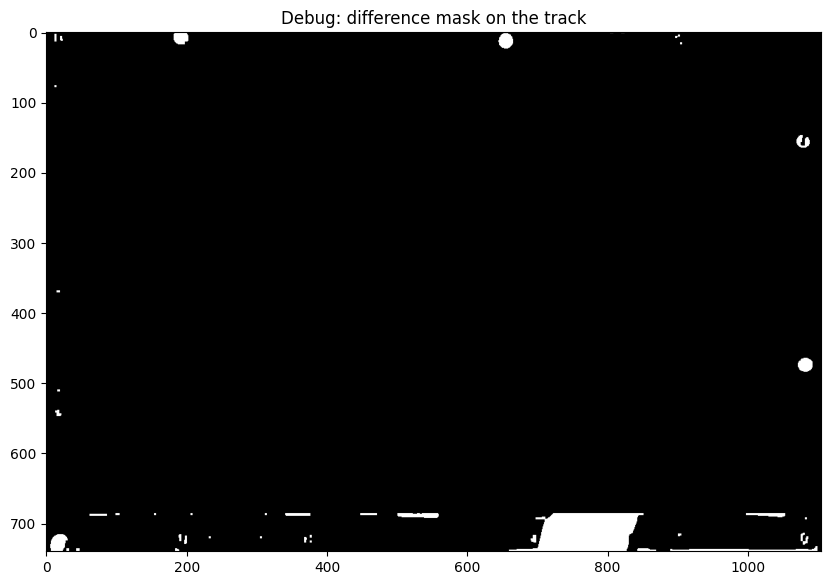

blob in  843 - 736 , discarded for area: 58.5
blob in  184 - 736 , discarded for area: 12.0
blob in  43 - 736 , discarded for area: 12.0
blob in  29 - 736 , discarded for area: 9.0
blob in  890 - 733 , discarded for size: 210 7
blob in  376 - 725 , discarded for area: 4.0
blob in  368 - 720 , discarded for area: 17.0
blob in  305 - 719 , discarded for area: 4.0
blob in  232 - 719 , discarded for area: 4.0
blob in  197 - 718 , discarded for area: 27.0
blob in  691 - 717 , discarded for area: 50.5
blob in  376 - 717 , discarded for area: 6.0
blob in  189 - 716 , discarded for area: 22.0
blob area=  426 box=25x24 HSV=[120  56  49] -> classe=None casella=0
blob in  901 - 715 , discarded for area: 10.5
blob area=   62 box=11x17 HSV=[ 14 102  80] -> classe=None casella=70
blob in  1082 - 692 , discarded for area: 4.0
blob in  62 - 687 , discarded for area: 48.0
blob in  998 - 686 , discarded for size: 56 6
blob in  660 - 686 , discarded for area: 6884.0
blob in  501 - 686 , discarded for siz

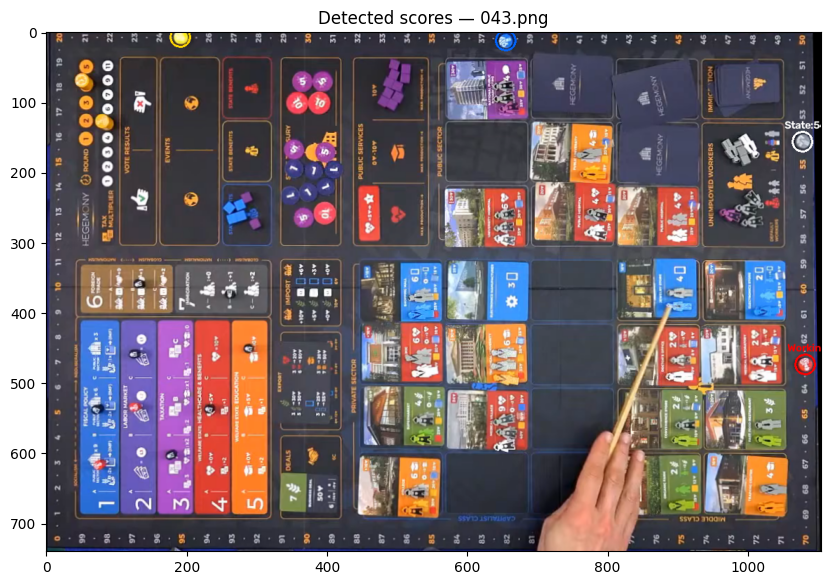

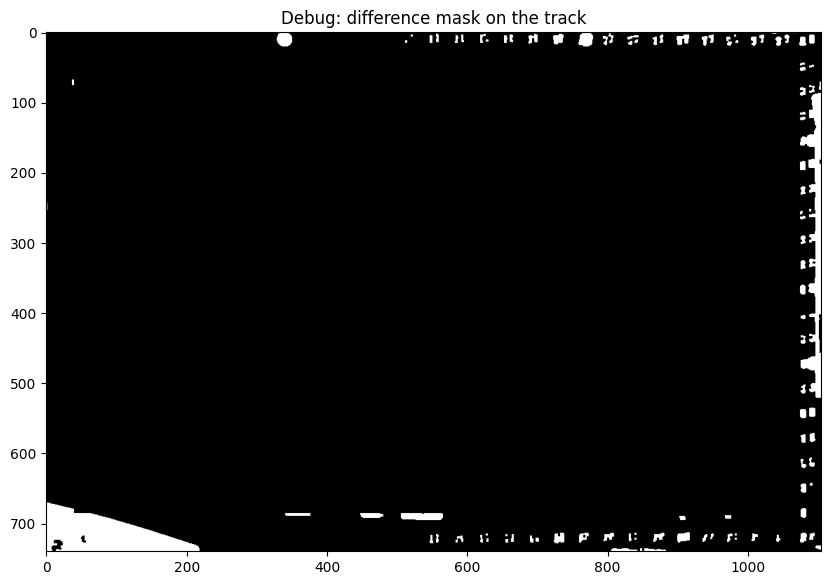

blob in  853 - 736 , discarded for area: 54.0
blob in  847 - 736 , discarded for area: 6.0
blob in  806 - 736 , discarded for size: 37 4
blob in  1097 - 732 , discarded for area: 28.5
blob in  655 - 723 , discarded for area: 12.0
blob in  628 - 722 , discarded for area: 8.0
blob in  982 - 721 , discarded for area: 4.0
blob in  839 - 721 , discarded for area: 4.0
blob in  698 - 721 , discarded for area: 18.5
blob in  690 - 718 , discarded for area: 28.0
blob in  584 - 718 , discarded for area: 36.0
blob in  1041 - 717 , discarded for area: 27.0
blob in  619 - 717 , discarded for area: 21.0
blob in  547 - 717 , discarded for area: 28.5
blob in  936 - 716 , discarded for area: 32.5
blob in  663 - 716 , discarded for area: 24.5
blob in  655 - 716 , discarded for area: 4.0
blob in  556 - 716 , discarded for area: 26.0
blob in  1006 - 715 , discarded for area: 43.0
blob in  982 - 715 , discarded for area: 4.0
blob in  971 - 715 , discarded for area: 36.0
blob in  947 - 715 , discarded for ar

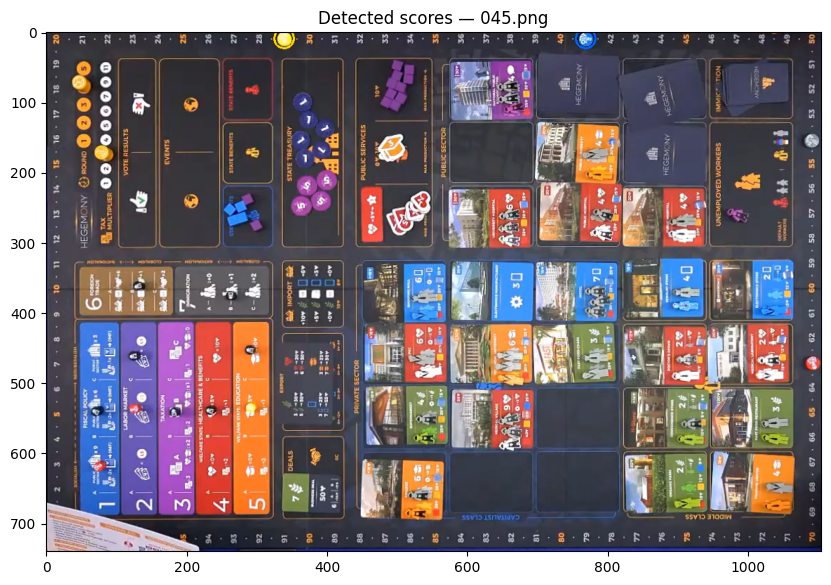

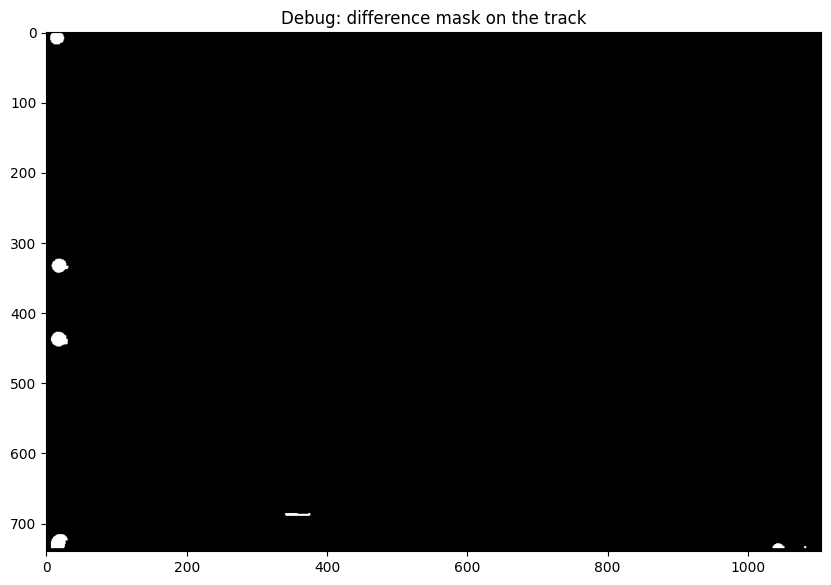

blob in  1081 - 733 , discarded for area: 4.0
blob in  1036 - 729 , discarded for aspect ratio: 2.4285714285714284
blob area=  350 box=24x20 HSV=[123  58  54] -> classe=None casella=0
blob in  341 - 686 , discarded for size: 36 4
blob area=  352 box=24x21 HSV=[105  94 241] -> classe=Capitalist casella=8
blob area=  313 box=24x20 HSV=[ 10  69 241] -> classe=Working casella=11
blob area=  278 box=20x19 HSV=[114  20 188] -> classe=State casella=20

047.png — Scores read: {'Capitalist': 8, 'Working': 11, 'State': 20}


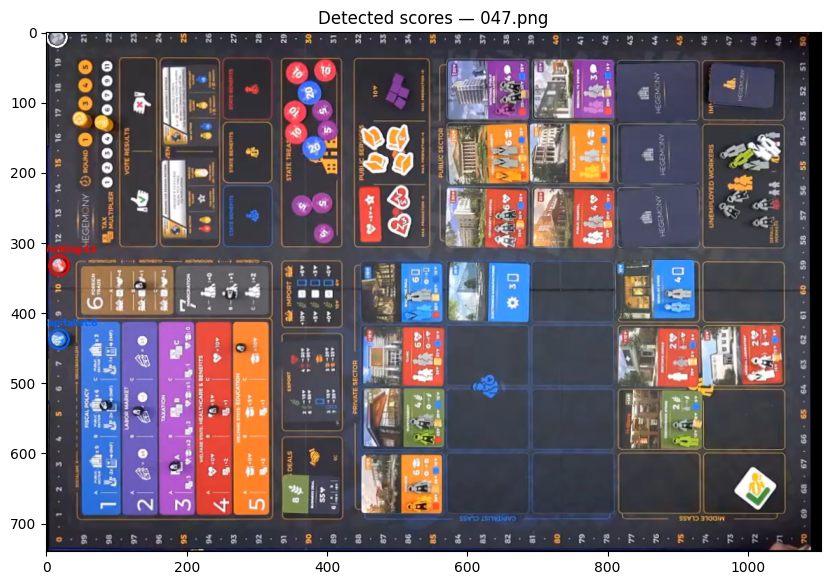

In [10]:
folder_path = "../dataset/Game_2/"
img1 = cv2.imread(os.path.join(folder_path, "043.png"))
img2 = cv2.imread(os.path.join(folder_path, "045.png"))
img3 = cv2.imread(os.path.join(folder_path, "020.png"))
# other sets tried: 041 027 019 / 007 039 035 / 025 015 017

CLASS_DRAW_COLORS = {"Working": (0, 0, 255),"Capitalist": (255, 100, 0),
    "Middle": (0, 215, 255), "State": (255, 255, 255),}


def read_scores(frame, debug=False, return_tokens=False):
    aligned, valid_mask = align_to_reference(frame)
    if aligned is None:
        return (None, None, []) if return_tokens else (None, None)

    tokens = detect_score_tokens(aligned, valid_mask, debug=debug, ring_mask=ring_mask)

    best = {}
    for t in tokens:
        if t["class"] not in best or t["area"] > best[t["class"]]["area"]:
            best[t["class"]] = t

    annotated = aligned.copy()
    for cls, t in best.items():
        color = CLASS_DRAW_COLORS.get(cls, (0, 255, 0))
        cv2.circle(annotated, t["center"], 14, color, 2)
        cv2.putText(annotated, f"{cls}:{t['score']}",
                    (t["center"][0] - 25, t["center"][1] - 18),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    scores = {cls: t["score"] for cls, t in best.items()}
    return (scores, annotated, tokens) if return_tokens else (scores, annotated)


# Test on three frames (defensive: does not crash if a frame fails)
for name, im in [("043.png", img1), ("045.png", img2), ("047.png", img3)]:
    scores, annotated = read_scores(im, debug=True)
    print(f"\n{name} — Scores read:", scores)
    if annotated is not None:
        show_image(annotated, f"Detected scores — {name}")
    else:
        print(f"{name}: alignment failed, no image")

## 8. Tracking Scores Throughout the Game

We apply `read_scores` to all frames in the folder. If a class is not detected in a frame (hand over the track, occluded disc), we keep the last known value (*carry forward*). The result is the score timeline.

In [11]:
def median3(seq):
    """Median filter with centered window of 3 (ignores None values)."""
    out = []
    for i in range(len(seq)):
        window = [v for v in seq[max(0, i-1):i+2] if v is not None]
        out.append(np.median(window) if window else None)
    return out


def isotonic(values):
    """Isotonic regression: scores never decrease.
    Gaps (None) are filled with the last known value; before
    the first reading, the score is 0 (start of the game)."""
    result = []
    current_max = 0                      # start of the game: score 0
    for v in values:
        if v is not None:
            current_max = max(current_max, v)
        result.append(current_max)       # also for None values: carry the last value
    return result


def track_game(folder, step=1, verbose=True):
    files = sorted(f for f in os.listdir(folder)
                   if f.lower().endswith((".png", ".jpg", ".jpeg")))
    files = files[::step]

    classes = list(CLASS_DRAW_COLORS.keys())
    raw = {c: [] for c in classes}
    frames_ok = []
    last = {c: 0 for c in classes}      # start of the game: score 0

    for fname in files:
        frame = cv2.imread(os.path.join(folder, fname))
        if frame is None:
            continue
        scores, _, tokens = read_scores(frame, return_tokens=True)
        if scores is None:
            if verbose:
                print(f"{fname}: alignment failed, frame skipped")
            continue
        for c in classes:
            cands = [t for t in tokens if t["class"] == c]
            if cands:
                chosen = min(cands, key=lambda t: abs(t["score"] - last[c]))
                raw[c].append(chosen["score"])
                last[c] = chosen["score"]
            else:
                raw[c].append(None)
        frames_ok.append(fname)

    timeline = {c: isotonic(median3(raw[c])) for c in classes}
    return frames_ok, timeline, raw


def evaluate(frames_ok, timeline, gold):
    classes = list(CLASS_DRAW_COLORS.keys())
    print(f"{'Class':<12}{'MAE':>7}{'Exact':>9}{'within ±1':>10}{'N':>5}")
    all_errs = []
    for c in classes:
        errs = []
        for i, f in enumerate(frames_ok):
            key = os.path.splitext(f)[0]
            if key in gold and timeline[c][i] is not None:
                errs.append(abs(timeline[c][i] - gold[key][c]))
        if errs:
            mae = np.mean(errs)
            exact = np.mean([e == 0 for e in errs]) * 100
            near = np.mean([e <= 1 for e in errs]) * 100
            print(f"{c:<12}{mae:>7.2f}{exact:>8.0f}%{near:>9.0f}%{len(errs):>5}")
            all_errs += errs
    print(f"{'TOTAL':<12}{np.mean(all_errs):>7.2f}"
          f"{np.mean([e == 0 for e in all_errs])*100:>8.0f}%"
          f"{np.mean([e <= 1 for e in all_errs])*100:>9.0f}%{len(all_errs):>5}")

    # the worst frames, to inspect with debug
    print("\nLarger errors:")
    worst = []
    for i, f in enumerate(frames_ok):
        key = os.path.splitext(f)[0]
        if key in gold:
            for c in classes:
                if timeline[c][i] is not None:
                    e = abs(timeline[c][i] - gold[key][c])
                    if e > 3:
                        worst.append((e, f, c, timeline[c][i], gold[key][c]))
    for e, f, c, p, g in sorted(worst, reverse=True)[:10]:
        print(f"  {f} {c}: predicted {p}, actual {g} (error {e})")



In [12]:
# GOLD STANDARD - Game 2 
GOLD = {
    "001": {"Capitalist": 0,  "Middle": 0,  "Working": 0,  "State": 0},
    "003": {"Capitalist": 0,  "Middle": 0,  "Working": 0,  "State": 0},
    "005": {"Capitalist": 0,  "Middle": 0,  "Working": 0,  "State": 0},
    "006": {"Capitalist": 0,  "Middle": 0,  "Working": 0,  "State": 0},
    "007": {"Capitalist": 0,  "Middle": 0,  "Working": 0,  "State": 0},
    "008": {"Capitalist": 0,  "Middle": 0,  "Working": 0,  "State": 0},
    "010": {"Capitalist": 0,  "Middle": 0,  "Working": 0,  "State": 2},
    "011": {"Capitalist": 0,  "Middle": 0,  "Working": 1,  "State": 8},
    "013": {"Capitalist": 0,  "Middle": 6,  "Working": 2,  "State": 9},
    "014": {"Capitalist": 0,  "Middle": 6,  "Working": 6,  "State": 10},
    "015": {"Capitalist": 0,  "Middle": 6,  "Working": 6,  "State": 10},
    "016": {"Capitalist": 0,  "Middle": 6,  "Working": 11, "State": 11},
    "017": {"Capitalist": 0,  "Middle": 6,  "Working": 11, "State": 11},
    "018": {"Capitalist": 0,  "Middle": 6,  "Working": 11, "State": 11},
    "019": {"Capitalist": 0,  "Middle": 6,  "Working": 11, "State": 11},
    "020": {"Capitalist": 8,  "Middle": 8,  "Working": 11, "State": 20},
    "021": {"Capitalist": 8,  "Middle": 8,  "Working": 16, "State": 21},
    "022": {"Capitalist": 8,  "Middle": 8,  "Working": 16, "State": 21},
    "023": {"Capitalist": 8,  "Middle": 8,  "Working": 22, "State": 21},
    "024": {"Capitalist": 8,  "Middle": 8,  "Working": 22, "State": 24},
    "026": {"Capitalist": 8,  "Middle": 11, "Working": 37, "State": 24},
    "027": {"Capitalist": 8,  "Middle": 11, "Working": 37, "State": 24},
    "029": {"Capitalist": 30, "Middle": 12, "Working": 37, "State": 28},
    "030": {"Capitalist": 30, "Middle": 12, "Working": 37, "State": 31},
    "031": {"Capitalist": 33, "Middle": 13, "Working": 37, "State": 31},
    "032": {"Capitalist": 33, "Middle": 16, "Working": 37, "State": 34},
    "033": {"Capitalist": 33, "Middle": 20, "Working": 43, "State": 35},
    "034": {"Capitalist": 33, "Middle": 20, "Working": 43, "State": 36},
    "035": {"Capitalist": 33, "Middle": 20, "Working": 50, "State": 36},
    "038": {"Capitalist": 31, "Middle": 20, "Working": 53, "State": 36},  
    "039": {"Capitalist": 38, "Middle": 22, "Working": 56, "State": 47},
    "040": {"Capitalist": 38, "Middle": 22, "Working": 63, "State": 47},
    "041": {"Capitalist": 38, "Middle": 22, "Working": 63, "State": 54},
    "042": {"Capitalist": 38, "Middle": 25, "Working": 63, "State": 54},
    "044": {"Capitalist": 38, "Middle": 28, "Working": 63, "State": 54},
    "047": {"Capitalist": 60, "Middle": 32, "Working": 71, "State": 63},
    "048": {"Capitalist": 60, "Middle": 39, "Working": 71, "State": 65},
    "049": {"Capitalist": 60, "Middle": 42, "Working": 71, "State": 65},
    "052": {"Capitalist": 68, "Middle": 45, "Working": 71, "State": 67},
    "054": {"Capitalist": 83, "Middle": 94, "Working": 80, "State": 80},
    "055": {"Capitalist": 96, "Middle": 94, "Working": 80, "State": 93},  
}

Class           MAE    Exact within ±1    N
Working        0.15      93%       98%   41
Capitalist     0.05      98%       98%   41
Middle         0.44      83%       85%   41
State          0.38      80%       98%   41
TOTAL          0.25      88%       95%  164

Larger errors:
  019.png State: predicted 20.0, actual 11 (error 9.0)
  011.png Middle: predicted 6.0, actual 0 (error 6.0)
  054.png Working: predicted 75.5, actual 80 (error 4.5)

Analyzed 44 frames


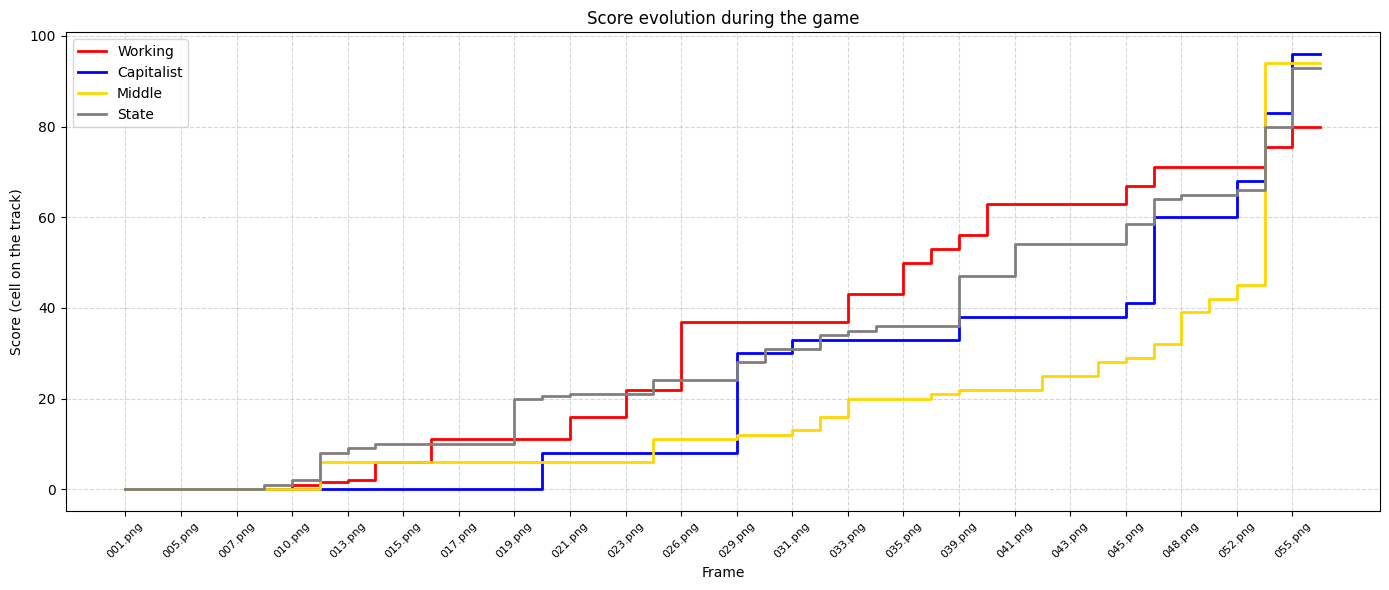

In [14]:
frames_ok, timeline, raw = track_game("../dataset/Game_2/", step=1, verbose=True)
evaluate(frames_ok, timeline, GOLD)
print(f"\nAnalyzed {len(frames_ok)} frames")

# Timeline plot
PLOT_COLORS = {"Working": "red", "Capitalist": "blue",
               "Middle": "gold", "State": "grey"}

plt.figure(figsize=(14, 6))
x = range(len(frames_ok))
for cls, values in timeline.items():
    vals = [v if v is not None else np.nan for v in values]
    plt.step(x, vals, where="post", label=cls,
             color=PLOT_COLORS.get(cls), linewidth=2)

plt.xticks(list(x)[::max(1, len(frames_ok)//15)],
           [frames_ok[i] for i in range(0, len(frames_ok), max(1, len(frames_ok)//15))],
           rotation=45, fontsize=8)
plt.ylabel("Score (cell on the track)")
plt.xlabel("Frame")
plt.title("Score evolution during the game")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
# Educational Appendix: Frame Analysis and Edge Detection
The following sections (from the original analysis notebook) compare preprocessing techniques and edge detection operators, and show the edge-based detection method initially used for the tokens. They are kept for **comparison and documentation purposes in the report**: the score reading in the main pipeline instead uses the difference from the empty-board reference (Sections 5–8), which is more robust for this task.

## A1. Preprocessing

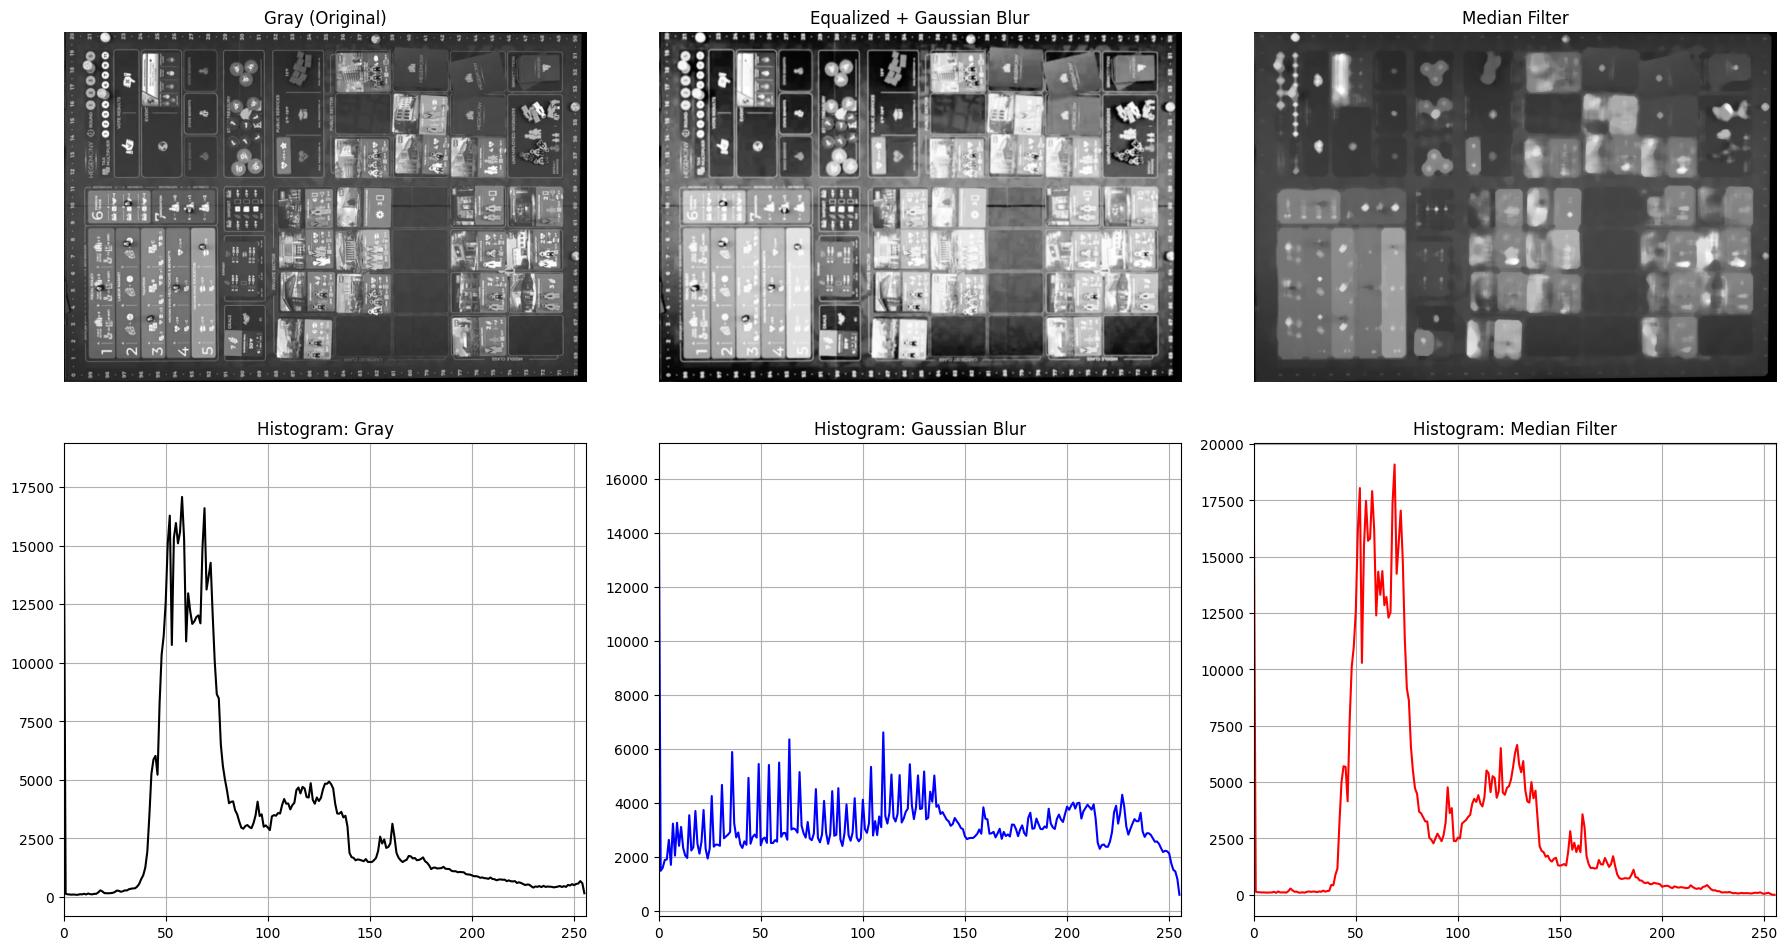

In [13]:
map_img = aligned.copy()

gray = cv2.cvtColor(map_img, cv2.COLOR_BGR2GRAY)
equalized = cv2.equalizeHist(gray)
blur_gaussian = cv2.GaussianBlur(equalized, (5, 5), 0)
blur_median = cv2.medianBlur(gray, 15)

hist_gray = cv2.calcHist([gray], [0], None, [256], [0, 256])
hist_gaussian = cv2.calcHist([blur_gaussian], [0], None, [256], [0, 256])
hist_median = cv2.calcHist([blur_median], [0], None, [256], [0, 256])

plt.figure(figsize=(18, 10))
plt.subplot(2, 3, 1); plt.imshow(gray, cmap='gray'); plt.title("Gray (Original)"); plt.axis("off")
plt.subplot(2, 3, 2); plt.imshow(blur_gaussian, cmap='gray'); plt.title("Equalized + Gaussian Blur"); plt.axis("off")
plt.subplot(2, 3, 3); plt.imshow(blur_median, cmap='gray'); plt.title("Median Filter"); plt.axis("off")
plt.subplot(2, 3, 4); plt.plot(hist_gray, color='black'); plt.title("Histogram: Gray"); plt.xlim([0, 256]); plt.grid(True)
plt.subplot(2, 3, 5); plt.plot(hist_gaussian, color='blue'); plt.title("Histogram: Gaussian Blur"); plt.xlim([0, 256]); plt.grid(True)
plt.subplot(2, 3, 6); plt.plot(hist_median, color='red'); plt.title("Histogram: Median Filter"); plt.xlim([0, 256]); plt.grid(True)
plt.tight_layout()
plt.show()

## A2. Comparison of Edge Detection Operators (Manual Implementations)

Processing manual operators (puo' richiedere qualche secondo)...
Processing complete!


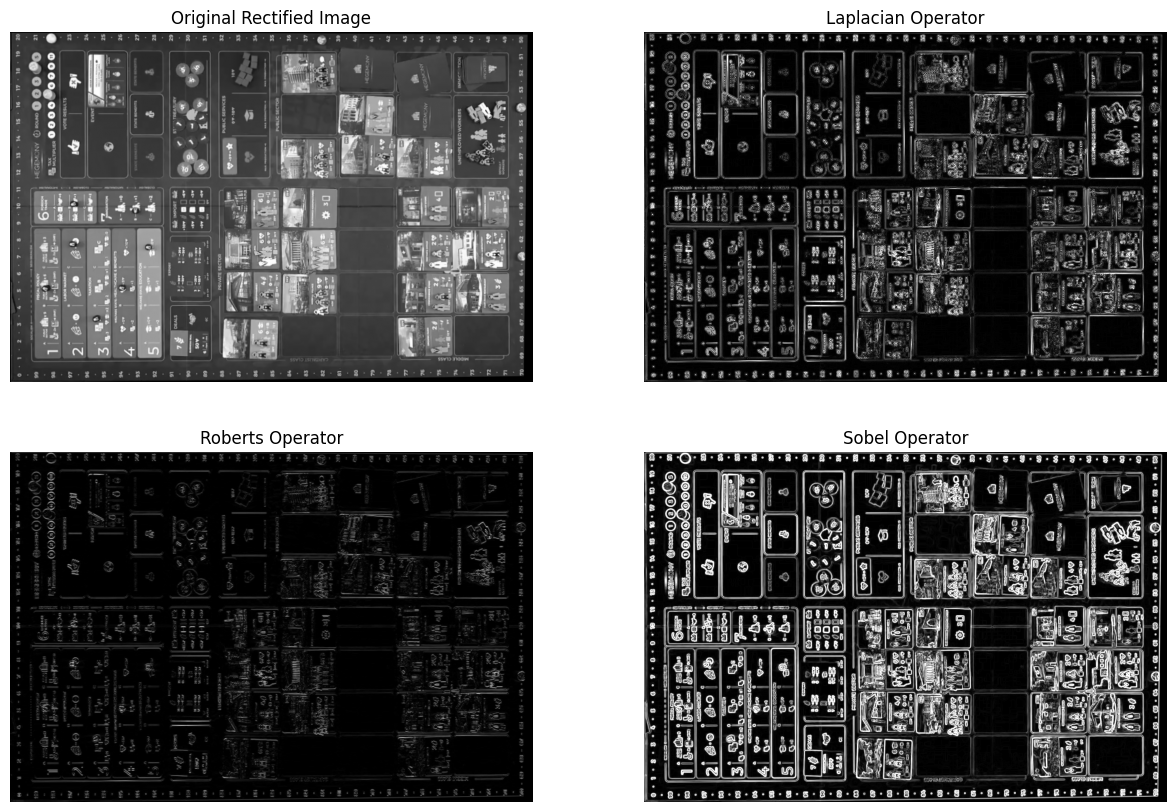

In [14]:
def robert(img):
    img = img.astype(np.int32).copy()
    out = np.zeros_like(img)
    r, c = img.shape
    kernel = np.array([[-1, -1], [1, 1]])
    for x in range(r - 1):
        for y in range(c - 1):
            out[x, y] = abs((kernel * img[x:x+2, y:y+2]).sum())
    return np.uint8(np.clip(out, 0, 255))

def sobel(img):
    img = img.astype(np.float64)
    r, c = img.shape
    new_image = np.zeros((r, c))
    kX = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
    kY = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]])
    for i in range(r - 2):
        for j in range(c - 2):
            gx = abs(np.sum(img[i:i+3, j:j+3] * kX))
            gy = abs(np.sum(img[i:i+3, j:j+3] * kY))
            new_image[i+1, j+1] = (gx**2 + gy**2) ** 0.5
    return np.uint8(np.clip(new_image, 0, 255))

def laplace(img):
    img = img.astype(np.float64)
    r, c = img.shape
    new_image = np.zeros((r, c))
    kL = np.array([[-1, -1, -1], [-1, 8, -1], [-1, -1, -1]])
    for i in range(r - 2):
        for j in range(c - 2):
            new_image[i+1, j+1] = abs(np.sum(img[i:i+3, j:j+3] * kL))
    return np.uint8(np.clip(new_image, 0, 255))

print("Processing manual operators (puo' richiedere qualche secondo)...")
img_laplace = laplace(gray)
img_robert  = robert(gray)
img_sobel   = sobel(gray)
print("Processing complete!")

plt.figure(figsize=(15, 10))
plt.subplot(221); plt.title("Original Rectified Image"); plt.imshow(gray, cmap="gray", vmin=0, vmax=255); plt.axis('off')
plt.subplot(222); plt.title("Laplacian Operator"); plt.imshow(img_laplace, cmap="gray", vmin=0, vmax=255); plt.axis('off')
plt.subplot(223); plt.title("Roberts Operator"); plt.imshow(img_robert, cmap="gray", vmin=0, vmax=255); plt.axis('off')
plt.subplot(224); plt.title("Sobel Operator"); plt.imshow(img_sobel, cmap="gray", vmin=0, vmax=255); plt.axis('off')
plt.show()

## A3. Canny and the Edge-Based Method (for Comparison with the Main Pipeline)
The edge-based method detects contours of both the printed numbers and the tokens, and must then separate them using geometric filters: this is its structural weakness for score tracking, and the reason why the main pipeline uses the difference from the empty-board reference instead.

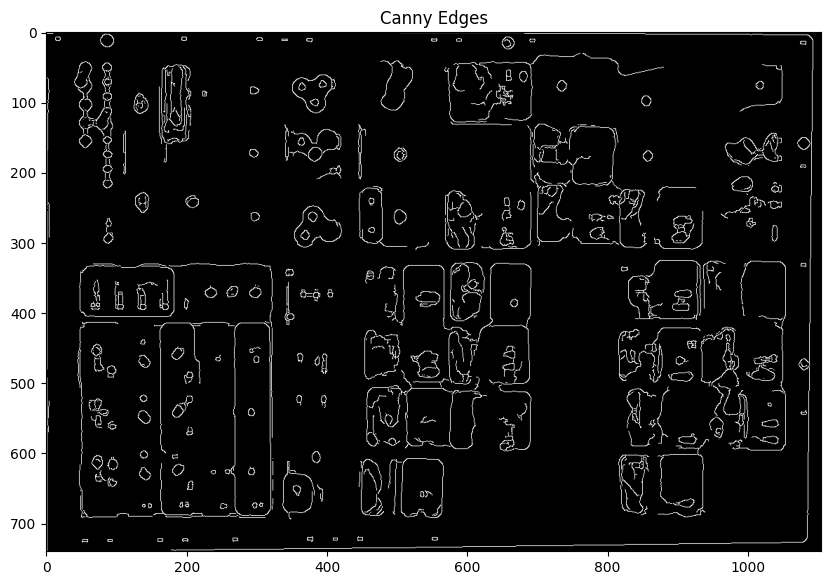

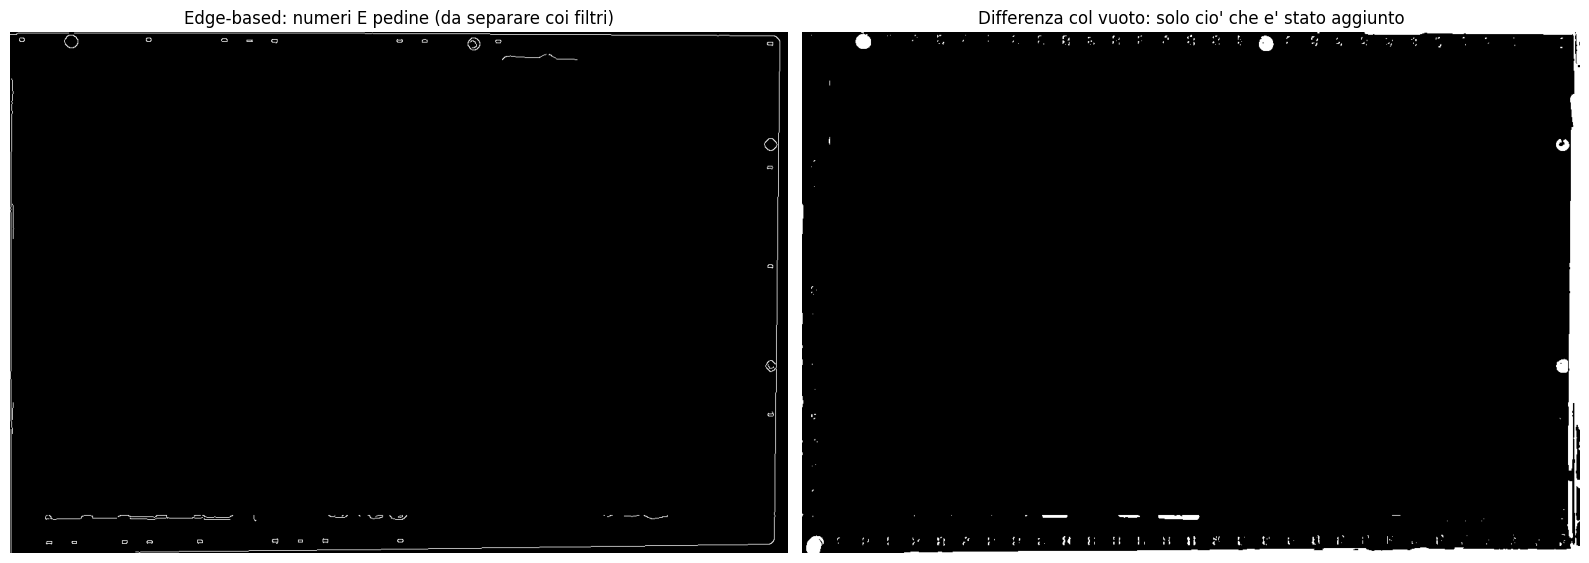

In [ ]:
edges = cv2.Canny(blur_median, 30, 100)
show_image(edges, "Canny Edges", cmap='gray')

# Direct comparison: what Canny sees vs. what the difference sees on the track
mask_canny = cv2.bitwise_and(edges, ring_mask)

frame_blur = cv2.GaussianBlur(map_img, (5, 5), 0)
diff = cv2.absdiff(frame_blur, _empty_blur).max(axis=2).astype(np.uint8)
_, mask_diff = cv2.threshold(cv2.bitwise_and(diff, ring_mask),
                             DIFF_THRESHOLD, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(16, 6))
plt.subplot(121); plt.imshow(mask_canny, cmap='gray')
plt.title("Edge-based: numbers AND tokens (to be separated with filters)"); plt.axis('off')
plt.subplot(122); plt.imshow(mask_diff, cmap='gray')
plt.title("Difference from empty: only what was added"); plt.axis('off')
plt.tight_layout()
plt.show()

## Conclusions
The final pipeline meets the project's objective (score tracking) by combining the strengths of the two approaches:
- from the geometric side: robust rectification via **homography** (ORB + GMS + RANSAC), which makes every frame comparable pixel by pixel with the reference;
- from the analysis side: the **track** model and reading via **difference + color classification**, an evolution of the initial background subtraction and contour-based detection.

Possible future work: extending the same technique to the other areas of the board (`locate_politics`).